# Binomial Option Pricing Model (CRR)
## Objective
-Implement a binomial tree pricer for European call/put options
-Explain the financial intuition (risk-neutral pricing & no-arbitrage)
-Validate results against the Black–Scholes closed-form solution
-Study convergence as the number of steps increases
##Model Intuition (CRR)
We discretize time into N steps. At each step, the stock moves:
Up: S⋅u
Down: S⋅d
where:
u=e^σsqrt(Δt),
d=1/u

Under the risk-neutral measure, the expected return of the stock is the risk-free rate r. This gives the probability:

p=e^(rΔt)−d/u−d
We then price the option by backward induction, discounting expected payoffs at each node.


## Imports


In [3]:
#3. IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt, log
from scipy.stats import norm



In [4]:
#4. Binomial pricer Implementation
def binomial_option_price(S, K, T, r, sigma, N, option_type="call"):
    """
    Price a European option using the Cox-Ross-Rubinstein binomial model.

    Parameters:
    S (float): Initial stock price
    K (float): Strike price
    T (float): Time to maturity (years)
    r (float): Risk-free rate
    sigma (float): Volatility
    N (int): Number of time steps
    option_type (str): 'call' or 'put'

    Returns:
    float: Option price
    """
    dt = T/N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    # Stock prices at maturity
    prices = np.array([S * (u**j) * (d**(N-j)) for j in range(N+1)])
     # Option payoffs at maturity
    if option_type == "call":
        values = np.maximum(prices - K, 0)
    else:
        values = np.maximum(K - prices, 0)
    # Backward induction
    for _ in range(N):
        values = np.exp(-r * dt) * (p * values[1:] + (1 - p) * values[:-1])

    return values[0]


## Why Backward Induction Works

At each node, the option value is the discounted expected payoff under the risk-neutral measure:

V = e^{-rΔt} [pV_up + (1-p)V_down]

This ensures no-arbitrage, since the expected return matches the risk-free rate.

In [5]:
# Black–Scholes Benchmark
def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    d1 = (log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * exp(-r*T) * norm.cdf(d2)
    else:
        return K * exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        

In [6]:
S, K, T = 100, 100, 1
r, sigma = 0.05, 0.2
N = 100

bin_price = binomial_option_price(S, K, T, r, sigma, N)
bs_price = black_scholes_price(S, K, T, r, sigma)

print(f"Binomial Price: {bin_price:.4f}")
print(f"Black-Scholes Price: {bs_price:.4f}")

Binomial Price: 10.4306
Black-Scholes Price: 10.4506


In [7]:
N_values = [10, 25, 50, 100, 200, 500]
bin_prices = []

for n in N_values:
    price = binomial_option_price(S, K, T, r, sigma, n)
    bin_prices.append(price)

bs_price = black_scholes_price(S, K, T, r, sigma)


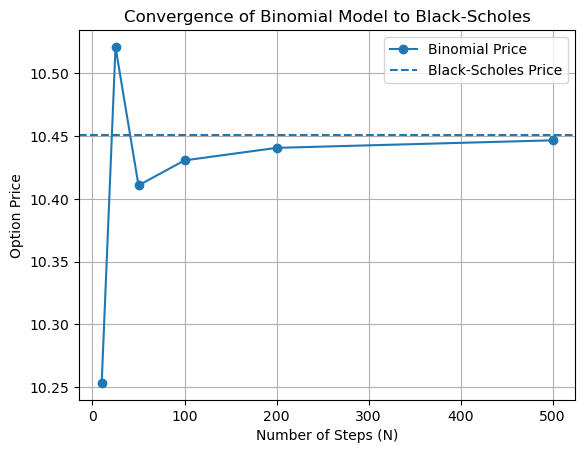

In [8]:
plt.plot(N_values, bin_prices, marker='o', label='Binomial Price')
plt.axhline(y=bs_price, linestyle='--', label='Black-Scholes Price')
plt.xlabel('Number of Steps (N)')
plt.ylabel('Option Price')
plt.title('Convergence of Binomial Model to Black-Scholes')
plt.legend()
plt.grid()
plt.show()

## 9. Key Insights
As N increases, the binomial price converges to Black–Scholes
The model enforces no-arbitrage via risk-neutral probability
Time complexity is O(N^2)

## 10. Requirements
numpy
matplotlib
scipy

## 11. How to Run
 -Install dependencies
 -Open the notebook
 -Run all cells

## 12. Summary

This project demonstrates:

Numerical methods in finance
Risk-neutral pricing
Model validation
Clean Python implementation

A strong foundation for quantitative finance and derivatives pricing.